# Snabb EDA: Kundbortfall på gym (churn)

**Förslag:** Förutsäga vilka gymmedlemmar som är på väg att säga upp sig, så att gymmet kan sätta in riktade åtgärder i tid.

Två dataset kontrolleras:
1. **Gym Members Exercise Dataset** (länken i förslaget): https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset
2. **Model Fitness Customer Churn** (det dataset som brukar användas för gym-churn): https://www.kaggle.com/datasets/ellanihill/model-fitness-customer-churn

**Licens:** Kontrollera på respektive Kaggle-sida och skriv in här.

In [1]:
import shutil
from pathlib import Path
 
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
 
RAW_DIR = Path("../data/raw/gym")
RAW_DIR.mkdir(parents=True, exist_ok=True)
 
DATASETS = {
    "exercise": "valakhorasani/gym-members-exercise-dataset",
    "churn": "ellanihill/model-fitness-customer-churn",
}
 
files = {}
for name, slug in DATASETS.items():
    cache = Path(kagglehub.dataset_download(slug))
    for f in cache.glob("*.csv"):
        target = RAW_DIR / f"{name}_{f.name}"
        shutil.copy2(f, target)
        files[name] = target
        print(f"{name}: {target.name}")

c:\Projekt Data Science\flotation-silica-prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 21.6k/21.6k [00:00<00:00, 14.4MB/s]

Extracting files...
exercise: exercise_gym_members_exercise_tracking.csv


100%|██████████| 133k/133k [00:00<00:00, 416kB/s]

Extracting files...
churn: churn_gym_churn_us.csv


## 1. Datasetet i förslaget: finns det en churn-kolumn?

In [2]:
exercise = pd.read_csv(files["exercise"])
print(exercise.shape)
print(exercise.columns.tolist())
 
candidates = [c for c in exercise.columns
              if any(w in c.lower() for w in ["churn", "cancel", "quit", "active", "member"])]
print("\nKolumner som skulle kunna vara ett churn-mål:", candidates or "inga")
 
# %% [markdown]
# ## 2. Model Fitness: översikt
 
# %%
df = pd.read_csv(files["churn"])
df.columns = df.columns.str.strip().str.lower()   # enhetliga kolumnnamn
 
print(df.shape)
df.info()
df.head()

(973, 15)
['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']

Kolumner som skulle kunna vara ett churn-mål: inga
(4000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   near_location                      4000 non-null   int64  
 2   partner                            4000 non-null   int64  
 3   promo_friends                      4000 non-null   int64  
 4   phone                              4000 non-null   int64  
 5   contract_period                    4000 non-null   int64  
 6   group_visits                       4000 non-null   int64  
 7   

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [3]:
print("Saknade värden:", df.isna().sum().sum())
print("Dubblerade rader:", df.duplicated().sum())
print(df.describe().round(2).T)

Saknade värden: 0
Dubblerade rader: 0
                                    count    mean    std    min    25%  \
gender                             4000.0    0.51   0.50   0.00   0.00   
near_location                      4000.0    0.85   0.36   0.00   1.00   
partner                            4000.0    0.49   0.50   0.00   0.00   
promo_friends                      4000.0    0.31   0.46   0.00   0.00   
phone                              4000.0    0.90   0.30   0.00   1.00   
contract_period                    4000.0    4.68   4.55   1.00   1.00   
group_visits                       4000.0    0.41   0.49   0.00   0.00   
age                                4000.0   29.18   3.26  18.00  27.00   
avg_additional_charges_total       4000.0  146.94  96.36   0.15  68.87   
month_to_end_contract              4000.0    4.32   4.19   1.00   1.00   
lifetime                           4000.0    3.72   3.75   0.00   1.00   
avg_class_frequency_total          4000.0    1.88   0.97   0.00   1.18   


## Målvariabel

In [4]:
print(df["churn"].value_counts())
print(f"Andel som slutat: {df['churn'].mean():.1%}")


churn
0    2939
1    1061
Name: count, dtype: int64
Andel som slutat: 26.5%


## Binära variabler: andel churn per grupp

In [5]:
binary_cols = [c for c in df.columns if c != "churn" and df[c].nunique() == 2]
for col in binary_cols:
    print(df.groupby(col)["churn"].agg(["mean", "size"])
          .rename(columns={"mean": "andel_churn", "size": "antal"}).round(3), "\n")

        andel_churn  antal
gender                    
0             0.265   1959
1             0.266   2041 

               andel_churn  antal
near_location                    
0                    0.397    619
1                    0.241   3381 

         andel_churn  antal
partner                    
0              0.333   2053
1              0.194   1947 

               andel_churn  antal
promo_friends                    
0                    0.313   2766
1                    0.158   1234 

       andel_churn  antal
phone                    
0            0.267    386
1            0.265   3614 

              andel_churn  antal
group_visits                    
0                   0.330   2351
1                   0.173   1649 



## Numeriska variabler: skillnad mellan de som stannar och de som slutar

In [6]:
num_cols = [c for c in df.columns if c not in binary_cols + ["churn"]]
print(df.groupby("churn")[num_cols].mean().round(2).T)

churn                                   0       1
contract_period                      5.75    1.73
age                                 29.98   26.99
avg_additional_charges_total       158.45  115.08
month_to_end_contract                5.28    1.66
lifetime                             4.71    0.99
avg_class_frequency_total            2.02    1.47
avg_class_frequency_current_month    2.03    1.04


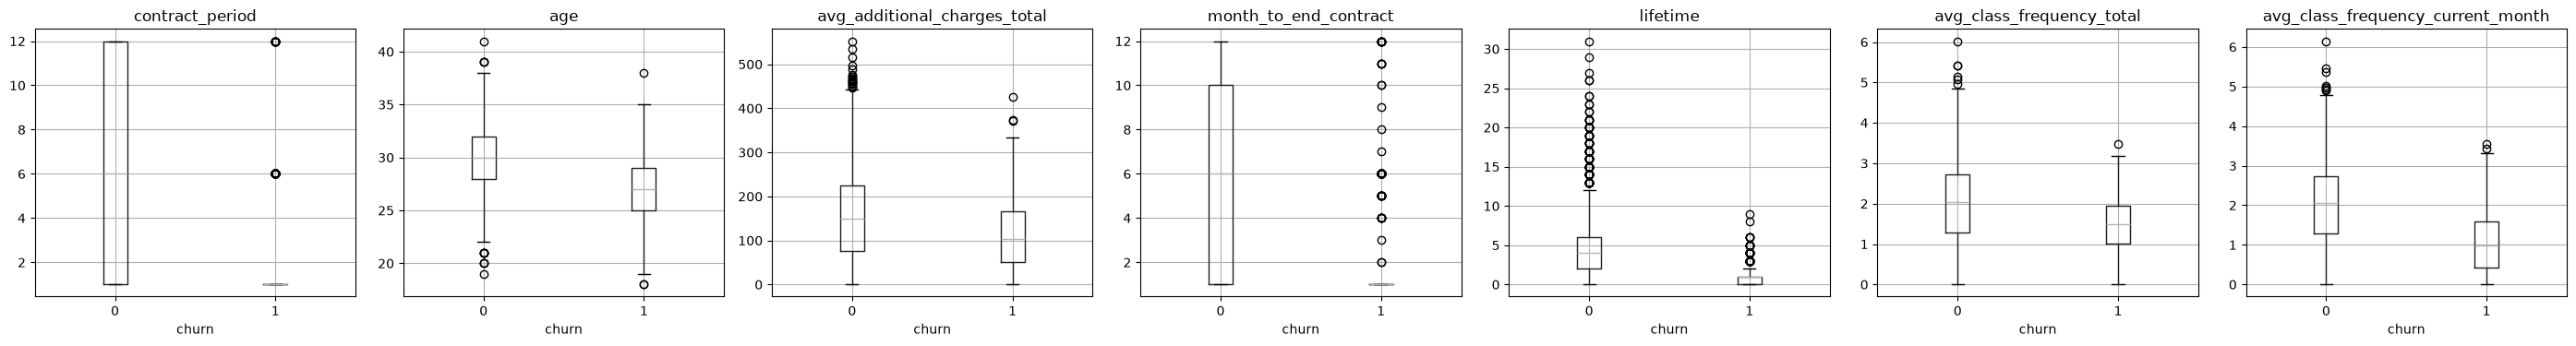

In [7]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(4 * len(num_cols), 4))
for ax, col in zip(axes, num_cols):
    df.boxplot(column=col, by="churn", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("churn")
plt.suptitle("")
plt.tight_layout()
plt.show()

## Kontrakt och tid som medlem

Kontraktslängd och tid kvar på kontraktet kan ge läckage: den som har långt kvar på sitt kontrakt kan per definition inte ha slutat.

In [8]:
if {"contract_period", "month_to_end_contract"} <= set(df.columns):
    print(pd.crosstab(df["contract_period"], df["churn"], normalize="index").round(3))
    print("\nChurn per antal månader kvar på kontraktet:")
    print(df.groupby("month_to_end_contract")["churn"].agg(["mean", "size"]).round(3))
 
if "lifetime" in df.columns:
    print("\nChurn per antal månader som medlem:")
    print(df.groupby("lifetime")["churn"].agg(["mean", "size"]).round(3).head(15))

churn                0      1
contract_period              
1                0.577  0.423
6                0.875  0.125
12               0.976  0.024

Churn per antal månader kvar på kontraktet:
                        mean  size
month_to_end_contract             
1.0                    0.423  2207
2.0                    0.143    14
3.0                    0.043    23
4.0                    0.121    58
5.0                    0.146   130
6.0                    0.118   645
7.0                    0.040    25
8.0                    0.026    38
9.0                    0.014    73
10.0                   0.024    82
11.0                   0.022   181
12.0                   0.025   524

Churn per antal månader som medlem:
           mean  size
lifetime             
0         0.828   487
1         0.491   843
2         0.257   610
3         0.102   490
4         0.060   383
5         0.029   273
6         0.018   220
7         0.000   167
8         0.009   111
9         0.010   100
10        0.00

## Enkel regelbaserad baseline

Förslaget: flagga medlemmar som slutat träna. Datan saknar "dagar sedan senaste besök", men träningsfrekvens den senaste månaden fungerar som närmevärde.

In [9]:
freq_col = next((c for c in df.columns if "current_month" in c), None)
if freq_col:
    for threshold in [0.5, 1.0, 1.5]:
        pred = (df[freq_col] < threshold).astype(int)
        tp = ((pred == 1) & (df["churn"] == 1)).sum()
        precision = tp / pred.sum() if pred.sum() else 0
        recall = tp / df["churn"].sum()
        print(f"Regel: {freq_col} < {threshold}  ->  "
              f"precision {precision:.2f}, recall {recall:.2f}, flaggade {pred.mean():.1%}")

Regel: avg_class_frequency_current_month < 0.5  ->  precision 0.58, recall 0.27, flaggade 12.6%
Regel: avg_class_frequency_current_month < 1.0  ->  precision 0.52, recall 0.51, flaggade 26.1%
Regel: avg_class_frequency_current_month < 1.5  ->  precision 0.45, recall 0.72, flaggade 42.3%


## Korrelationer

lifetime                            -0.44
avg_class_frequency_current_month   -0.41
age                                 -0.40
contract_period                     -0.39
month_to_end_contract               -0.38
avg_class_frequency_total           -0.25
avg_additional_charges_total        -0.20
group_visits                        -0.18
promo_friends                       -0.16
partner                             -0.16
near_location                       -0.13
phone                               -0.00
gender                               0.00
Name: churn, dtype: float64


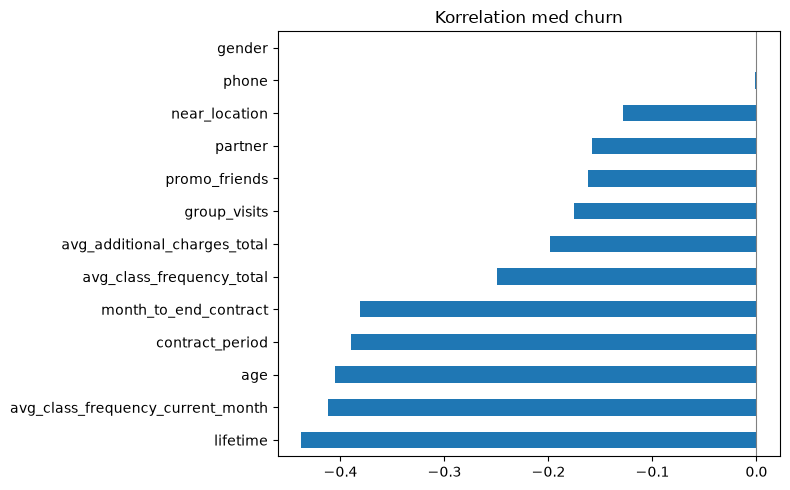

In [10]:
corr = df.corr(numeric_only=True)["churn"].drop("churn").sort_values()
print(corr.round(2))
 
corr.plot(kind="barh", figsize=(8, 5), title="Korrelation med churn")
plt.axvline(0, color="gray", linewidth=0.8)
plt.tight_layout()
plt.show()

In [11]:
import kagglehub
from pathlib import Path
import pandas as pd

path = Path(kagglehub.dataset_download("hassaan2580/churn-prediction-gym-members-dataset"))
print([f.name for f in path.iterdir()])

new = pd.read_csv(next(path.glob("*.csv")))
print(new.shape)
new.info()
new.head()

100%|██████████| 6.17k/6.17k [00:00<00:00, 7.74MB/s]

Extracting files...
['gym_members_dataset.csv']
(150, 15)
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Member_ID                 150 non-null    int64  
 1   Name                      127 non-null    str    
 2   Age                       137 non-null    float64
 3   Gender                    150 non-null    str    
 4   Address                   150 non-null    str    
 5   Phone_Number              150 non-null    str    
 6   Membership_Type           150 non-null    str    
 7   Join_Date                 141 non-null    str    
 8   Last_Visit_Date           150 non-null    str    
 9   Favorite_Exercise         150 non-null    str    
 10  Avg_Workout_Duration_Min  150 non-null    int64  
 11  Avg_Calories_Burned       139 non-null    float64
 12  Total_Weight_Lifted_kg    142 non-null    float64
 13  Visits_Per_Month  

,Member_ID,Name,Age,Gender,Address,Phone_Number,Membership_Type,Join_Date,Last_Visit_Date,Favorite_Exercise,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month,Churn
0,1,NaN,19.0,Male,"Street 171, City 39",032-51510359,Quarterly,2022-07-23,2022-11-03,Pull-ups,93,214.0,13995.0,18.0,No
1,2,Shanza,19.0,Female,"Street 111, City 18",039-19243328,Monthly,2023-12-04,2024-02-14,Squats,37,436.0,4612.0,11.0,No
2,3,Ubaidullah,52.0,Male,"Street 69, City 21",033-60221501,Quarterly,2024-09-13,2024-12-07,Bench Press,98,523.0,3124.0,4.0,Yes
3,4,Mansoor Ahmed,52.0,Male,"Street 72, City 39",035-55527902,Monthly,2024-06-05,2025-02-24,Pull-ups,66,282.0,4586.0,24.0,No
4,5,Hanzala,32.0,Male,"Street 6, City 12",038-93946322,Monthly,2022-06-15,2022-12-02,Bench Press,32,522.0,16353.0,18.0,No


In [12]:
# Är det samma data som Model Fitness?
new_cols = set(new.columns.str.strip().str.lower())
print("Gemensamma kolumner med Model Fitness:", new_cols & set(df.columns))
print("Nya kolumner:", new_cols - set(df.columns))

# Churn-andel och datakvalitet
target = next((c for c in new.columns if "churn" in c.lower()), None)
print("Målkolumn:", target)
if target:
    print(new[target].value_counts(normalize=True).round(3))
print("Saknade värden:", new.isna().sum().sum())
print("Dubblerade rader:", new.duplicated().sum())

Gemensamma kolumner med Model Fitness: {'churn', 'age', 'gender'}
Nya kolumner: {'last_visit_date', 'total_weight_lifted_kg', 'member_id', 'phone_number', 'membership_type', 'join_date', 'avg_workout_duration_min', 'address', 'favorite_exercise', 'avg_calories_burned', 'name', 'visits_per_month'}
Målkolumn: Churn
Churn
No     0.74
Yes    0.26
Name: proportion, dtype: float64
Saknade värden: 76
Dubblerade rader: 0


In [13]:
new.columns = new.columns.str.strip().str.lower()

# 1. Ser personuppgifterna påhittade ut?
print(new[["name", "phone_number", "address"]].head(5))

# Ta bort dem direkt
new = new.drop(columns=["name", "phone_number", "address"])

# 2. Var finns de saknade värdena?
print(new.isna().sum()[new.isna().sum() > 0])

# 3. Dagar sedan senaste besök – förklarar det churn helt?
new["last_visit_date"] = pd.to_datetime(new["last_visit_date"])
new["join_date"] = pd.to_datetime(new["join_date"])
ref = new["last_visit_date"].max()
new["days_since_visit"] = (ref - new["last_visit_date"]).dt.days

print(new.groupby("churn")["days_since_visit"].describe().round(0))
print("Datumintervall:", new["join_date"].min().date(), "-", new["last_visit_date"].max().date())

            name  phone_number              address
0            NaN  032-51510359  Street 171, City 39
1         Shanza  039-19243328  Street 111, City 18
2     Ubaidullah  033-60221501   Street 69, City 21
3  Mansoor Ahmed  035-55527902   Street 72, City 39
4        Hanzala  038-93946322    Street 6, City 12
age                       13
join_date                  9
avg_calories_burned       11
total_weight_lifted_kg     8
visits_per_month          12
dtype: int64
       count   mean    std    min    25%    50%    75%     max
churn                                                         
No     111.0  564.0  329.0    0.0  284.0  545.0  826.0  1208.0
Yes     39.0  565.0  302.0  119.0  313.0  552.0  839.0  1079.0
Datumintervall: 2022-01-09 - 2025-07-10
